In [265]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os

In [266]:
# Load privately owned public spaces and format the data
spaces = pd.read_csv("./pops/Privately_Owned_Public_Spaces__POPS__20250310.csv")

spaces = spaces.dropna(subset=["Latitude", "Longitude", "Year_Completed"])
spaces["ZIP Code"] = spaces['Building_Address_With_Zip_Code'].str.split().str[-1]
spaces = spaces[spaces['Borough'] == "Manhattan"]
spaces = spaces[spaces["Year_Completed"] != 0]

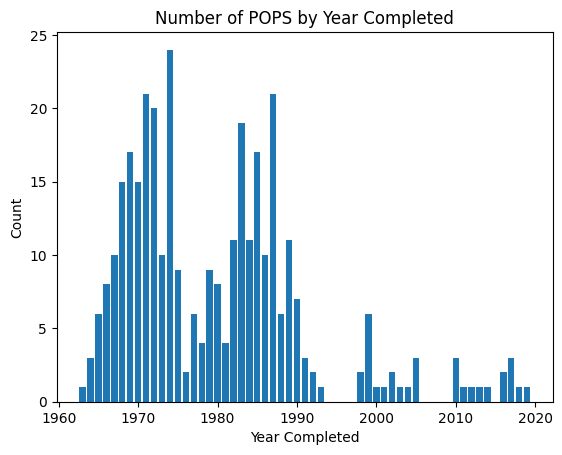

In [267]:
values, counts = np.unique(spaces["Year_Completed"], return_counts=True)
plt.bar(values, counts)
plt.title("Number of POPS by Year Completed")
plt.xlabel("Year Completed")
plt.ylabel("Count")
plt.show()

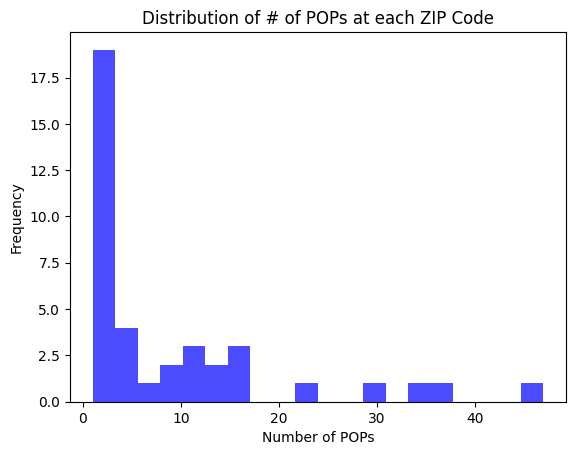

In [268]:
values, zip_code_pop_counts = np.unique(spaces['ZIP Code'], return_counts=True)

pop_values, pop_counts = np.unique(zip_code_pop_counts, return_counts=True)
plt.hist(zip_code_pop_counts, bins=20, color='blue', alpha=0.7, label='POP Counts')
plt.xlabel('Number of POPs')
plt.ylabel('Frequency')
plt.title('Distribution of # of POPs at each ZIP Code')
plt.show()

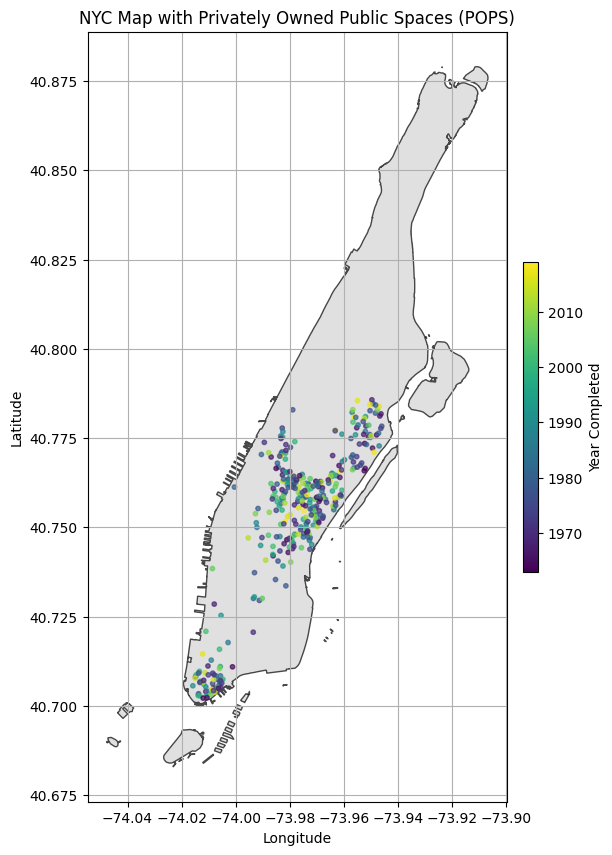

In [269]:
# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(spaces["Longitude"], spaces["Latitude"]), 
    crs="EPSG:4326"
)

# Read NYC map
nyc_map = gpd.read_file(get_path("nybb")).to_crs(epsg=4326)
manhattan_map = nyc_map[nyc_map["BoroName"] == "Manhattan"]

# Define colormap and normalization
cmap = plt.cm.viridis  # Use the viridis colormap
norm = mcolors.Normalize(vmin=spaces["Year_Completed"].min(), vmax=spaces["Year_Completed"].max())

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))
manhattan_map.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.7)

# Plot points with assigned colors
gdf_points.plot(ax=ax, cmap=cmap, markersize=10, alpha=0.7)

# Create a colorbar (sidebar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Year Completed")

# Titles and labels
plt.title("NYC Map with Privately Owned Public Spaces (POPS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

In [270]:
br2_rent_standard = 'SAFMR 2BR'
br1_rent_standard = 'SAFMR 1BR'

safmr_2025 = pd.read_csv("safmr/fy2025.csv")
safmr_2025 = safmr_2025[['ZIP Code', br1_rent_standard]]
safmr_2025[br1_rent_standard] = (
    safmr_2025[br1_rent_standard]
    .replace({'\$': '', ',': ''}, regex=True)
    .astype(float)
)
safmr_2025['ZIP Code'] = safmr_2025['ZIP Code'].astype(str)

safmr_2019 = pd.read_csv("safmr/fy2019.csv")
safmr_2019 = safmr_2019[['ZIP Code', br1_rent_standard]]
safmr_2019[br1_rent_standard] = (
    safmr_2019[br1_rent_standard]
    .replace({'\$': '', ',': ''}, regex=True)
    .astype(float)
)
safmr_2019['ZIP Code'] = safmr_2019['ZIP Code'].astype(str)

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_25016\2918112545.py:8: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)
C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_25016\2918112545.py:17: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


In [271]:
gdf = gpd.read_file('zipcode/geo_export_b459f634-6bcb-46d7-ade3-b0ef95b76ebc.shp')
gdf['label'] = gdf['label'].str.split(',').str[0]
gdf['label'] = gdf['label'].astype(str)

In [272]:
merged_df_2025 = gdf.merge(
    safmr_2025,
    how='left',
    left_on='label',
    right_on='ZIP Code'
)

merged_df_2025 = merged_df_2025.dropna(subset=['ZIP Code'])
merged_df_2025.drop(columns=['label', 'zcta', 'modzcta'], inplace=True)
merged_df_2025

,pop_est,geometry,ZIP Code,SAFMR 1BR
0,23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",10001,3220.0
1,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",10002,2210.0
2,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",10003,3500.0
3,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",10026,2270.0
4,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",10004,3320.0
...,...,...,...,...
175,36489.0,"POLYGON ((-73.79437 40.68691, -73.79478 40.687...",11433,2210.0
176,65989.0,"POLYGON ((-73.75461 40.6472, -73.7538 40.6467,...",11434,2210.0
177,59296.0,"POLYGON ((-73.80577 40.68293, -73.80606 40.683...",11435,2270.0
178,21354.0,"POLYGON ((-73.86496 40.56663, -73.86558 40.567...",11694,2210.0


In [273]:
merged_df_2019 = gdf.merge(
    safmr_2019,
    how='left',
    left_on='label',
    right_on='ZIP Code'
)

merged_df_2019 = merged_df_2019.dropna(subset=['ZIP Code'])
merged_df_2019.drop(columns=['label', 'zcta', 'modzcta'], inplace=True)
merged_df_2019

,pop_est,geometry,ZIP Code,SAFMR 1BR
0,23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",10001,2040.0
1,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",10002,1410.0
2,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",10003,2400.0
3,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",10026,1480.0
4,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",10004,2400.0
...,...,...,...,...
174,36489.0,"POLYGON ((-73.79437 40.68691, -73.79478 40.687...",11433,1540.0
175,65989.0,"POLYGON ((-73.75461 40.6472, -73.7538 40.6467,...",11434,1410.0
176,59296.0,"POLYGON ((-73.80577 40.68293, -73.80606 40.683...",11435,1620.0
177,21354.0,"POLYGON ((-73.86496 40.56663, -73.86558 40.567...",11694,1450.0


In [274]:
manhattan_shapes = merged_df_2025[merged_df_2025['ZIP Code'].astype(int) < 10282].copy()
manhattan_shapes['ZIP Code'] = manhattan_shapes['ZIP Code'].astype(str)
manhattan_shapes.to_csv('./output/manhattan_shapes.csv', index=False)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


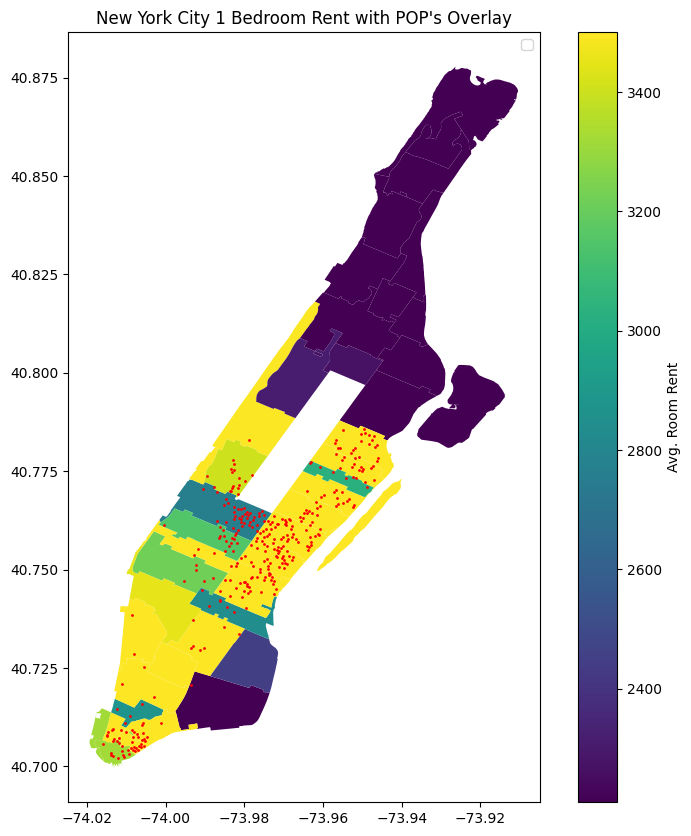

In [275]:
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=manhattan_shapes[br1_rent_standard].min(), vmax=manhattan_shapes[br1_rent_standard].max())

fig, ax = plt.subplots(figsize=(10, 10))

manhattan_shapes.plot(ax=ax, column=br1_rent_standard, cmap=cmap, legend=True, legend_kwds={'label': "Avg. Room Rent", 'orientation': "vertical"})

ax.set_title("New York City 1 Bedroom Rent with POP's Overlay")
ax.legend()

geometry = [Point(lon, lat) for lon, lat in zip(spaces['Longitude'], spaces['Latitude'])]
lat_lon_gdf = gpd.GeoDataFrame(spaces, geometry=geometry)

# Plot lat/long data points
lat_lon_gdf.plot(ax=ax, color='red', markersize=1, label="Lat/Lon Points")


plt.show()

In [276]:
merged = merged_df_2019.merge(
    merged_df_2025,
    on='ZIP Code',
    suffixes=('_old', '_new') 
)
merged['SAFMR_1BR_change'] = merged['SAFMR 1BR_new'] - merged['SAFMR 1BR_old']
merged.drop(columns=['pop_est_new', 'geometry_new'], inplace=True)
merged['SAFMR_1BR_PERC_CHANGE'] = (
    merged['SAFMR_1BR_change'] / merged['SAFMR 1BR_old']
)

pop_zip_codes, pop_counts = np.unique(spaces["ZIP Code"], return_counts=True)
merged['pops_count'] = merged['ZIP Code'].map(dict(zip(pop_zip_codes, pop_counts)))
merged['pops_count'] = merged['pops_count'].fillna(0)

avg_rent_increase_df = merged

In [277]:
non_pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] == 0]
pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] > 0]

In [278]:
print("Non POPS:", non_pops['SAFMR 1BR_new'].mean(), non_pops['SAFMR_1BR_change'].mean(), non_pops['SAFMR_1BR_PERC_CHANGE'].mean())
print("POPS:", pops['SAFMR 1BR_new'].mean(), pops['SAFMR_1BR_change'].mean(), pops['SAFMR_1BR_PERC_CHANGE'].mean())

Non POPS: 2424.458598726115 760.891719745223 0.4635118135031598
POPS: 3310.0 1008.8 0.4485686802121159


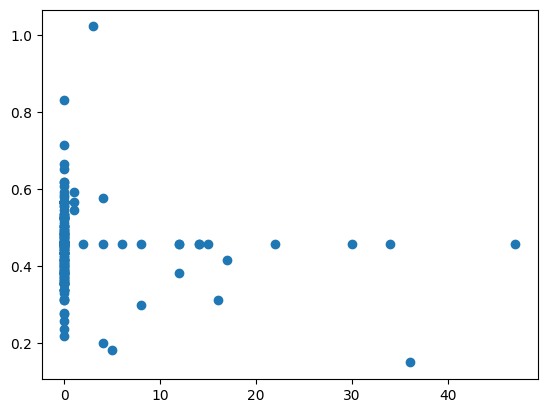

In [279]:
plt.plot(avg_rent_increase_df['pops_count'], avg_rent_increase_df['SAFMR_1BR_PERC_CHANGE'], 'o', label='POPS Count vs. Rent Change')